# Searchlight Merged Results Visualization

Meaningful visualization focused on statistically significant results (q ≤ 0.05).


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import plotting
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path('/Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight')
DIRS = {
    'ext': BASE / 'ext' / 'merged' / 'permutation',
    'rst': BASE / 'rst' / 'merged' / 'permutation',
    'dyn_ext': BASE / 'dyn_ext' / 'merged' / 'permutation',
    'dyn_rst': BASE / 'dyn_rst' / 'merged' / 'permutation',
    'crossphase': BASE / 'crossphase' / 'merged' / 'permutation',
}

for k, v in DIRS.items():
    print(f"{k}: {v} (exists={v.exists()})")

DIRS_CROSSHALF = {
    'ext': BASE / 'ext' / 'crosshalf_permutation',
    'rst': BASE / 'rst' / 'crosshalf_permutation',
    'dyn_ext': BASE / 'dyn_ext' / 'crosshalf_permutation',
    'dyn_rst': BASE / 'dyn_rst' / 'crosshalf_permutation',
    'crossphase': BASE / 'crossphase' / 'crosshalf_permutation',
}

for k, v in DIRS_CROSSHALF.items():
    print(f"{k} crosshalf: {v} (exists={v.exists()})")


ext: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/ext/merged/permutation (exists=True)
rst: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/rst/merged/permutation (exists=True)
dyn_ext: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/dyn_ext/merged/permutation (exists=True)
dyn_rst: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/dyn_rst/merged/permutation (exists=True)
crossphase: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/crossphase/merged/permutation (exists=True)
ext crosshalf: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/ext/crosshalf_permutation (exists=True)
rst crosshalf: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/rst/crosshalf_permutation (exists=True)
dyn_ext crosshalf: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/dyn_ext/crosshalf_permutation (exists=False)
dyn_rst crosshalf: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/dyn_rst/crosshalf_permutation (exists=False)
crossphase crosshalf: /Users/xiaoqianxiao/projects/NAR

## Helpers


In [2]:
def list_files(folder: Path, pattern: str):
    return sorted(folder.glob(pattern)) if folder.exists() else []


def _is_3d(img):
    return len(img.shape) == 3


def load_validmask(effect_path: Path, q_path: Path) -> np.ndarray | None:
    base = q_path.name.replace('_q.nii.gz', '')
    vm = effect_path.parent / f"{base}_validmask.nii.gz"
    if vm.exists():
        return nib.load(str(vm)).get_fdata() > 0
    return None


def plot_effect_with_q(effect_path: Path, q_path: Path, title: str, cmap: str = "RdBu_r", q_thresh: float = 0.05):
    effect_img = nib.load(str(effect_path))
    q_img = nib.load(str(q_path))
    if not _is_3d(effect_img) or not _is_3d(q_img):
        print(f"Skip non-3D image: {effect_path.name} or {q_path.name}")
        return None
    effect_data = effect_img.get_fdata()
    q_data = q_img.get_fdata()
    valid = load_validmask(effect_path, q_path)
    if valid is not None:
        q_data = np.where(valid, q_data, np.nan)
    sig_mask = (q_data <= q_thresh) & np.isfinite(q_data)
    if not np.any(sig_mask):
        return None
    n_sig = int(np.sum(sig_mask))
    print(f"Significant voxels ({n_sig} voxels): {q_path.name}")
    masked = np.where(sig_mask, effect_data, 0.0)
    out_img = nib.Nifti1Image(masked, effect_img.affine)
    display = plotting.plot_stat_map(out_img, title=title, display_mode="ortho", threshold=0, cmap=cmap)
    return display


def show_csv(path: Path, n: int = 10):
    if not path.exists():
        print(f"Missing: {path}")
        return None
    df = pd.read_csv(path)
    if len(df) == 0:
        return None
    display(df.head(n))
    print(f"Rows: {len(df)}")
    return df


In [ ]:
ORDER = [
    ("SAD_PLC", "SAD PLC"),
    ("HC_PLC", "HC PLC"),
    ("SAD-HC_PLC", "SAD vs HC (PLC)"),
    ("SAD_OXT-PLC", "OXT-PLC in SAD"),
    ("HC_OXT-PLC", "OXT-PLC in HC"),
    ("SAD-HC_OXT-PLC", "OXT-PLC SAD vs HC"),
]
CONDS = ["CS-", "CSS", "CSR"]
PAIRS = ["CS-_vs_CSS", "CS-_vs_CSR", "CSS_vs_CSR"]
METRICS = ["delta", "slope"]
HALF_SUFFIXES = ["", "_H1", "_H2"]


def _effect_path(folder: Path, base: str) -> Path | None:
    for suffix in ["_diff.nii.gz", "_mean.nii.gz"]:
        candidate = folder / f"{base}{suffix}"
        if candidate.exists():
            return candidate
    return None


def plot_ordered_ext_rst(folder: Path, key: str):
    print("")
    print(f"=== {key.upper()} ===")
    for cond in CONDS:
        for contrast, label in ORDER:
            if contrast in ["SAD_PLC", "HC_PLC"]:
                base = f"within_{cond}_{contrast}"
            elif contrast == "SAD-HC_PLC":
                base = f"diff_{cond}_{contrast}"
            else:
                base = f"mod_{cond}_{contrast}"
            q_path = folder / f"{base}_q.nii.gz"
            if not q_path.exists():
                continue
            effect_path = _effect_path(folder, base)
            if effect_path is None:
                continue
            plot_effect_with_q(effect_path, q_path, title=f"{key}: {cond} | {label}")

    sig_csvs = list_files(folder, "*_sig.csv")
    for csv_path in sig_csvs:
        df = show_csv(csv_path, n=10)
        if df is None:
            continue
        print("")
        print(csv_path.name)


def plot_ordered_dyn(folder: Path, key: str):
    print("")
    print(f"=== {key.upper()} ===")
    for pair in PAIRS:
        for metric in METRICS:
            for contrast, label in ORDER:
                base = f"{pair}_{contrast}_{metric}"
                q_path = folder / f"{base}_q.nii.gz"
                if not q_path.exists():
                    continue
                effect_path = _effect_path(folder, base)
                if effect_path is None:
                    continue
                plot_effect_with_q(effect_path, q_path, title=f"{key}: {pair} | {metric} | {label}")



=== EXT ===
Significant voxels (3 voxels): mod_CS-_SAD_OXT-PLC_q.nii.gz
Significant voxels (11 voxels): mod_CSR_HC_OXT-PLC_q.nii.gz


,x,y,z,effect,q,Name,LabelID,Atlas,contrast,Condition,Group
0,-36.0,-30.0,21.0,-0.062931,0.048190,48\t17Networks_LH_SomMotB_S2_2\t43\t204\t162\t0,48,Schaefer,modulation,CS-,SAD
1,-36.0,-27.0,21.0,-0.059031,0.036993,48\t17Networks_LH_SomMotB_S2_2\t43\t204\t162\t0,48,Schaefer,modulation,CS-,SAD
2,-33.0,-27.0,18.0,-0.055123,0.044591,48\t17Networks_LH_SomMotB_S2_2\t43\t204\t162\t0,48,Schaefer,modulation,CS-,SAD


Rows: 3

mod_CS-_SAD_OXT-PLC_sig.csv


,x,y,z,effect,q,Name,LabelID,Atlas,contrast,Condition,Group
0,-39.0,-90.0,18.0,0.062122,0.048990,10\t17Networks_LH_VisCent_ExStr_9\t120\t18\t14...,10,Schaefer,modulation,CSR,HC
1,-36.0,-90.0,9.0,0.062580,0.047191,10\t17Networks_LH_VisCent_ExStr_9\t120\t18\t14...,10,Schaefer,modulation,CSR,HC
2,-36.0,-87.0,15.0,0.061015,0.045391,10\t17Networks_LH_VisCent_ExStr_9\t120\t18\t14...,10,Schaefer,modulation,CSR,HC
3,-36.0,-87.0,18.0,0.061495,0.047391,10\t17Networks_LH_VisCent_ExStr_9\t120\t18\t14...,10,Schaefer,modulation,CSR,HC
4,-36.0,-84.0,15.0,0.077322,0.030994,10\t17Networks_LH_VisCent_ExStr_9\t120\t18\t14...,10,Schaefer,modulation,CSR,HC
5,-36.0,-84.0,18.0,0.071793,0.030994,65\t17Networks_LH_DorsAttnA_ParOcc_2\t74\t156\...,65,Schaefer,modulation,CSR,HC
6,-33.0,-87.0,9.0,0.069478,0.047391,10\t17Networks_LH_VisCent_ExStr_9\t120\t18\t14...,10,Schaefer,modulation,CSR,HC
7,-33.0,-84.0,15.0,0.063374,0.042991,10\t17Networks_LH_VisCent_ExStr_9\t120\t18\t14...,10,Schaefer,modulation,CSR,HC
8,-33.0,-84.0,18.0,0.068111,0.031994,65\t17Networks_LH_DorsAttnA_ParOcc_2\t74\t156\...,65,Schaefer,modulation,CSR,HC
9,-33.0,-81.0,15.0,0.072804,0.032793,10\t17Networks_LH_VisCent_ExStr_9\t120\t18\t14...,10,Schaefer,modulation,CSR,HC


Rows: 11

mod_CSR_HC_OXT-PLC_sig.csv


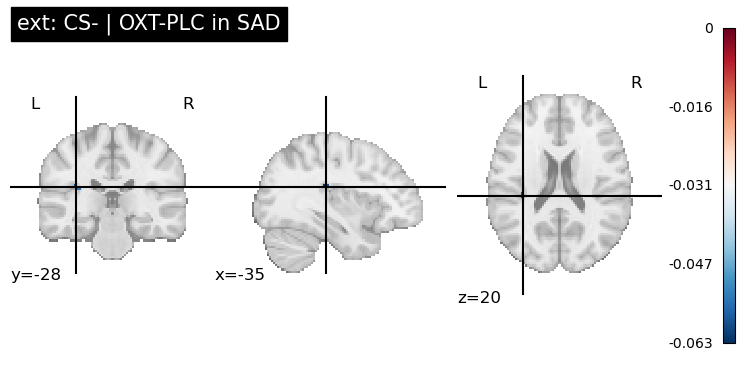

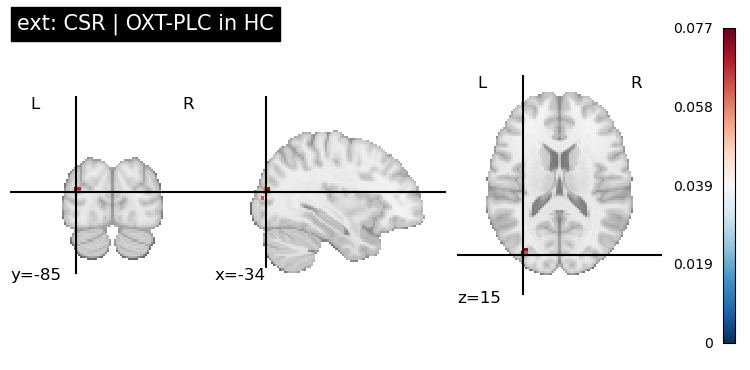

In [4]:
folder = DIRS["ext"]
if folder.exists():
    plot_ordered_ext_rst(folder, "ext")

plotting.show()


In [5]:
folder = DIRS["rst"]
if folder.exists():
    plot_ordered_ext_rst(folder, "rst")

plotting.show()



=== RST ===



Dynamic summary contrasts


,Pair,Metric,Contrast,N_sig_vox
0,CS-_vs_CSS,delta,SAD PLC (mean>0),0
1,CS-_vs_CSS,delta,HC PLC (mean>0),0
2,CS-_vs_CSS,delta,SAD-HC PLC,0
3,CS-_vs_CSS,delta,SAD OXT-PLC,0
4,CS-_vs_CSS,delta,HC OXT-PLC,0
5,CS-_vs_CSS,delta,SAD-HC OXT-PLC,0
6,CS-_vs_CSS,slope,SAD PLC (mean>0),2
7,CS-_vs_CSS,slope,HC PLC (mean>0),0
8,CS-_vs_CSS,slope,SAD-HC PLC,0
9,CS-_vs_CSS,slope,SAD OXT-PLC,0


Rows: 36

Dynamic significant voxels


,Contrast,Pair,Metric,x,y,z,p,q,Name,LabelID,Atlas
0,CS-_vs_CSS_SAD_PLC_slope,CS-_vs_CSS,slope,9.0,45.0,3.0,0.046191,0.046191,370\t17Networks_RH_DefaultA_PFCm_3\t249\t255\t...,370,Schaefer
1,CS-_vs_CSS_SAD_PLC_slope,CS-_vs_CSS,slope,9.0,48.0,3.0,0.048390,0.048390,370\t17Networks_RH_DefaultA_PFCm_3\t249\t255\t...,370,Schaefer
2,CS-_vs_CSR_SAD_PLC_delta,CS-_vs_CSR,delta,36.0,3.0,33.0,0.041792,0.041792,334\t17Networks_RH_ContA_PFCl_5\t233\t148\t38\t0,334,Schaefer
3,CS-_vs_CSR_SAD_PLC_delta,CS-_vs_CSR,delta,36.0,3.0,36.0,0.040992,0.040992,334\t17Networks_RH_ContA_PFCl_5\t233\t148\t38\t0,334,Schaefer
4,CS-_vs_CSR_SAD_PLC_delta,CS-_vs_CSR,delta,36.0,3.0,39.0,0.037193,0.037193,334\t17Networks_RH_ContA_PFCl_5\t233\t148\t38\t0,334,Schaefer
5,CS-_vs_CSR_SAD_PLC_delta,CS-_vs_CSR,delta,39.0,0.0,33.0,0.041992,0.041992,334\t17Networks_RH_ContA_PFCl_5\t233\t148\t38\t0,334,Schaefer
6,CS-_vs_CSR_SAD_PLC_delta,CS-_vs_CSR,delta,39.0,0.0,36.0,0.040992,0.040992,334\t17Networks_RH_ContA_PFCl_5\t233\t148\t38\t0,334,Schaefer
7,CS-_vs_CSR_SAD_PLC_delta,CS-_vs_CSR,delta,39.0,3.0,36.0,0.041992,0.041992,334\t17Networks_RH_ContA_PFCl_5\t233\t148\t38\t0,334,Schaefer
8,CS-_vs_CSR_SAD_PLC_delta,CS-_vs_CSR,delta,39.0,3.0,39.0,0.041792,0.041792,334\t17Networks_RH_ContA_PFCl_5\t233\t148\t38\t0,334,Schaefer
9,CS-_vs_CSR_SAD_PLC_delta,CS-_vs_CSR,delta,39.0,3.0,42.0,0.043191,0.043191,334\t17Networks_RH_ContA_PFCl_5\t233\t148\t38\t0,334,Schaefer


Rows: 347

=== DYN_EXT ===
Significant voxels (2 voxels): CS-_vs_CSS_SAD_PLC_slope_q.nii.gz
Significant voxels (77 voxels): CS-_vs_CSR_SAD_PLC_delta_q.nii.gz
Significant voxels (54 voxels): CS-_vs_CSR_SAD_PLC_slope_q.nii.gz
Significant voxels (214 voxels): CSS_vs_CSR_SAD_OXT-PLC_slope_q.nii.gz


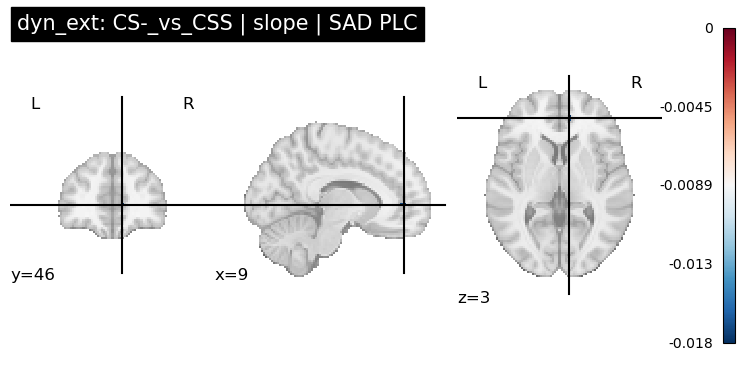

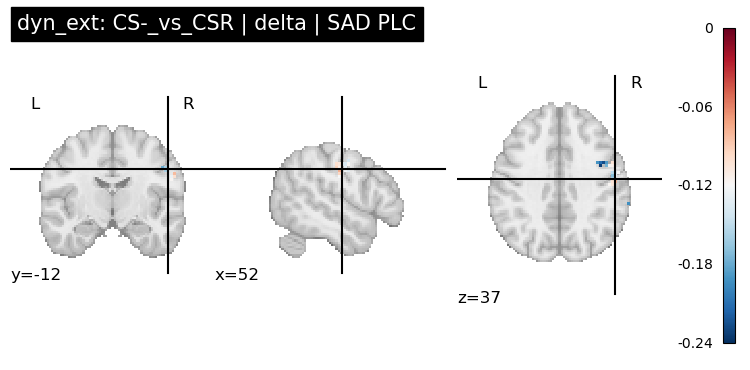

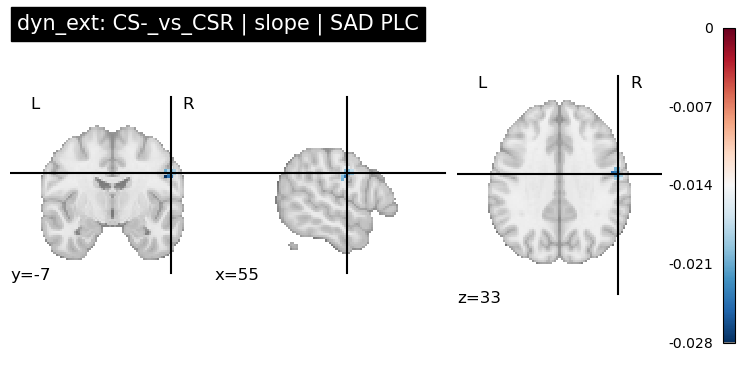

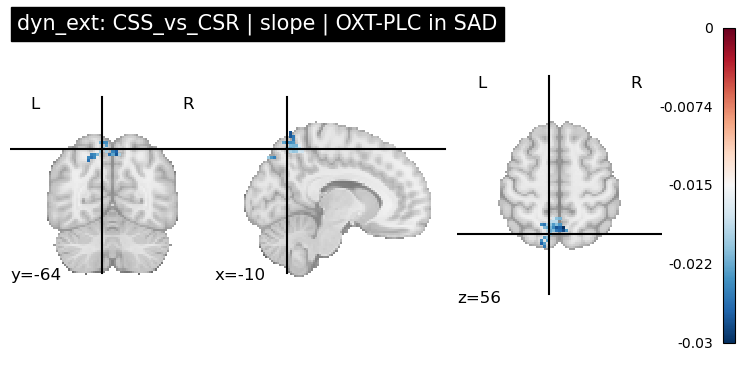

In [6]:
folder = DIRS["dyn_ext"]
if folder.exists():
    summary_path = folder / "dynamic_summary_contrasts.csv"
    if summary_path.exists():
        print("")
        print("Dynamic summary contrasts")
        show_csv(summary_path, n=10)

    sig_path = folder / "dynamic_sig_merged.csv"
    if sig_path.exists():
        print("")
        print("Dynamic significant voxels")
        df = pd.read_csv(sig_path)
        display(df.head(10))
        print(f"Rows: {len(df)}")

    plot_ordered_dyn(folder, "dyn_ext")

plotting.show()



Dynamic summary contrasts


,Pair,Metric,Contrast,N_sig_vox
0,CS-_vs_CSS,delta,SAD PLC (mean>0),0
1,CS-_vs_CSS,delta,HC PLC (mean>0),166
2,CS-_vs_CSS,delta,SAD-HC PLC,0
3,CS-_vs_CSS,delta,SAD OXT-PLC,0
4,CS-_vs_CSS,delta,HC OXT-PLC,7
5,CS-_vs_CSS,delta,SAD-HC OXT-PLC,0
6,CS-_vs_CSS,slope,SAD PLC (mean>0),0
7,CS-_vs_CSS,slope,HC PLC (mean>0),11592
8,CS-_vs_CSS,slope,SAD-HC PLC,0
9,CS-_vs_CSS,slope,SAD OXT-PLC,0


Rows: 36

Dynamic significant voxels


,Contrast,Pair,Metric,x,y,z,p,q,Name,LabelID,Atlas
0,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-60.0,-57.0,12.0,0.044191,0.044191,199\t17Networks_LH_TempPar_5\t9\t41\t252\t0,199,Schaefer
1,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-60.0,-54.0,9.0,0.039192,0.039192,199\t17Networks_LH_TempPar_5\t9\t41\t252\t0,199,Schaefer
2,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-60.0,-51.0,6.0,0.043191,0.043191,199\t17Networks_LH_TempPar_5\t9\t41\t252\t0,199,Schaefer
3,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-57.0,-69.0,15.0,0.037193,0.037193,64\t17Networks_LH_DorsAttnA_ParOcc_1\t74\t155\...,64,Schaefer
4,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-57.0,-66.0,12.0,0.048590,0.048590,121\t17Networks_LH_ContA_Temp_1\t230\t148\t35\t0,121,Schaefer
5,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-57.0,-66.0,15.0,0.032593,0.032593,64\t17Networks_LH_DorsAttnA_ParOcc_1\t74\t155\...,64,Schaefer
6,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-57.0,-57.0,9.0,0.039192,0.039192,199\t17Networks_LH_TempPar_5\t9\t41\t252\t0,199,Schaefer
7,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-57.0,-57.0,12.0,0.045191,0.045191,199\t17Networks_LH_TempPar_5\t9\t41\t252\t0,199,Schaefer
8,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-57.0,-54.0,6.0,0.037193,0.037193,199\t17Networks_LH_TempPar_5\t9\t41\t252\t0,199,Schaefer
9,CS-_vs_CSS_HC_PLC_delta,CS-_vs_CSS,delta,-57.0,-54.0,9.0,0.034593,0.034593,199\t17Networks_LH_TempPar_5\t9\t41\t252\t0,199,Schaefer


Rows: 17930

=== DYN_RST ===
Significant voxels (166 voxels): CS-_vs_CSS_HC_PLC_delta_q.nii.gz
Significant voxels (7 voxels): CS-_vs_CSS_HC_OXT-PLC_delta_q.nii.gz
Significant voxels (11592 voxels): CS-_vs_CSS_HC_PLC_slope_q.nii.gz
Significant voxels (8 voxels): CS-_vs_CSR_SAD_PLC_slope_q.nii.gz
Significant voxels (147 voxels): CS-_vs_CSR_HC_PLC_slope_q.nii.gz
Significant voxels (1 voxels): CSS_vs_CSR_SAD_PLC_delta_q.nii.gz
Significant voxels (16 voxels): CSS_vs_CSR_HC_PLC_delta_q.nii.gz
Significant voxels (5993 voxels): CSS_vs_CSR_SAD_PLC_slope_q.nii.gz


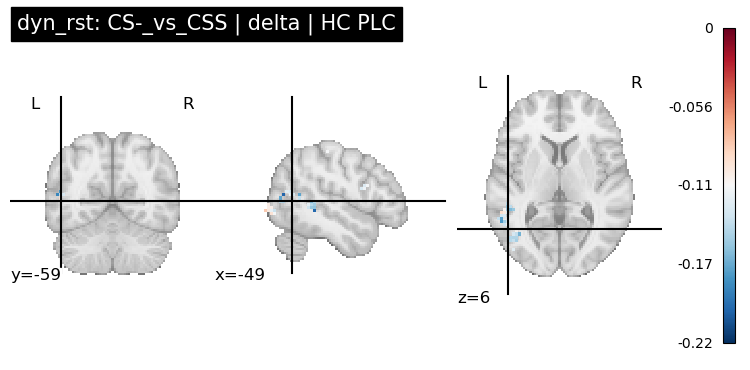

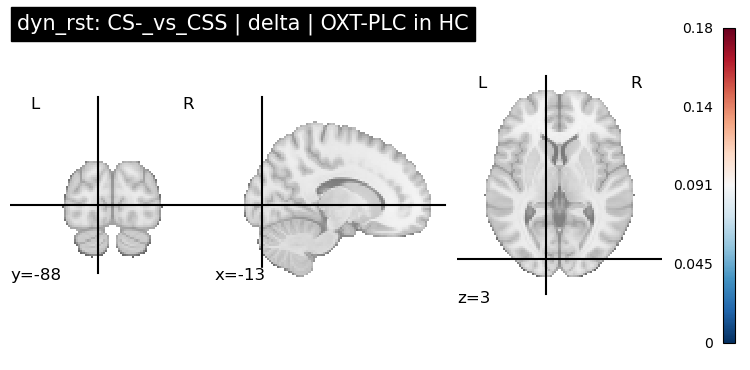

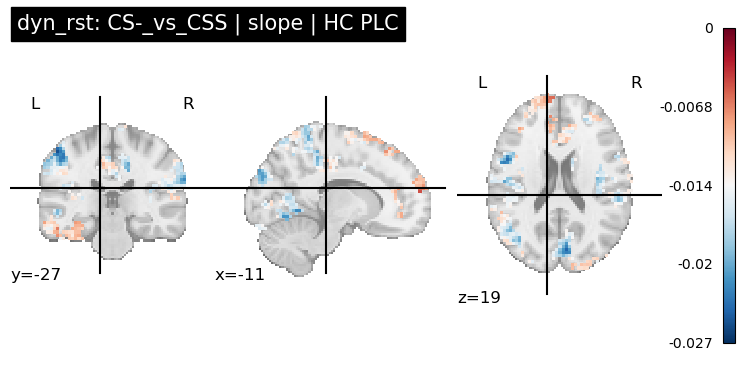

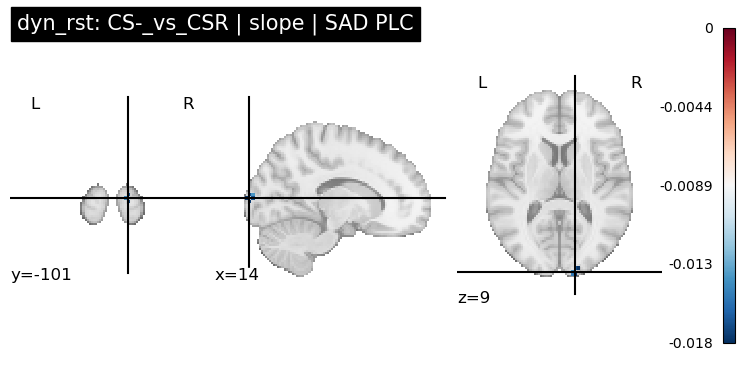

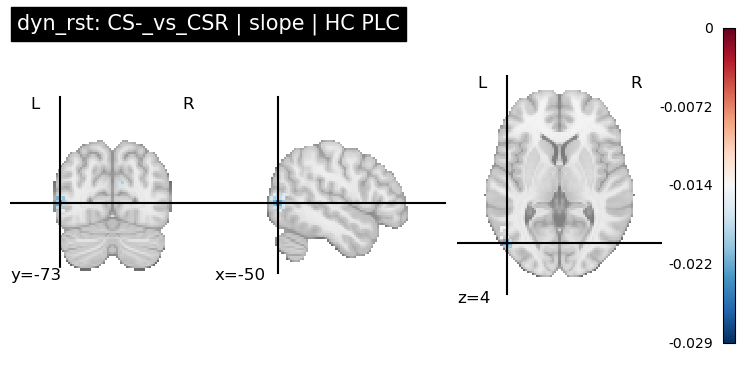

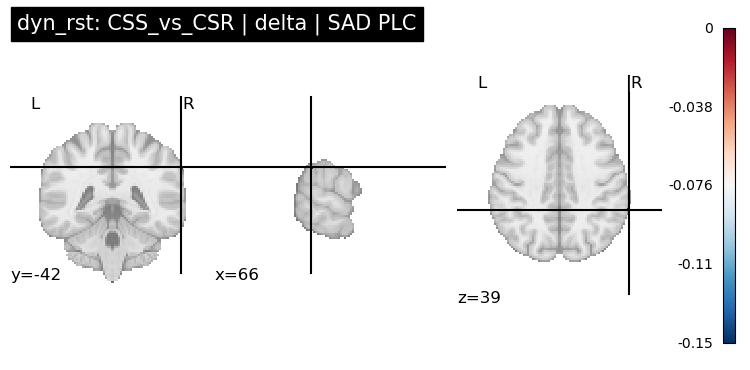

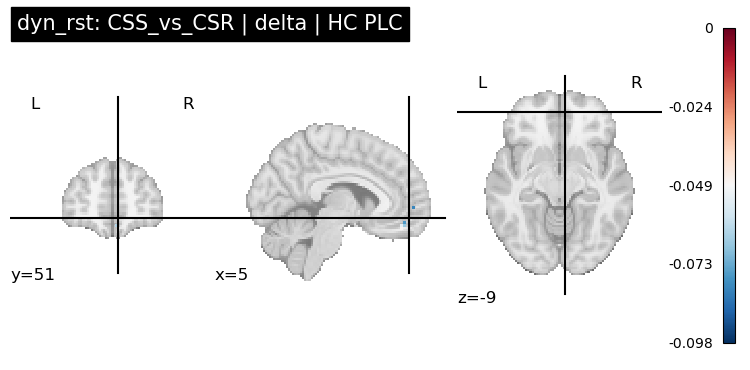

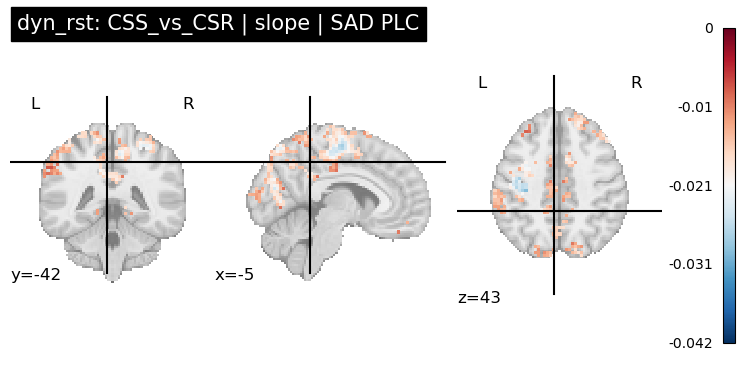

In [7]:
folder = DIRS["dyn_rst"]
if folder.exists():
    summary_path = folder / "dynamic_summary_contrasts.csv"
    if summary_path.exists():
        print("")
        print("Dynamic summary contrasts")
        show_csv(summary_path, n=10)

    sig_path = folder / "dynamic_sig_merged.csv"
    if sig_path.exists():
        print("")
        print("Dynamic significant voxels")
        df = pd.read_csv(sig_path)
        display(df.head(10))
        print(f"Rows: {len(df)}")

    plot_ordered_dyn(folder, "dyn_rst")

plotting.show()



Cross-phase summary contrasts


,Condition,Contrast,N_sig_vox
0,CS-,SAD PLC (mean>0),281
1,CS-,HC PLC (mean>0),694
2,CS-,SAD-HC PLC,0
3,CS-,SAD OXT-PLC,0
4,CS-,HC OXT-PLC,0
5,CS-,SAD-HC OXT-PLC,0
6,CSS,SAD PLC (mean>0),485
7,CSS,HC PLC (mean>0),1264
8,CSS,SAD-HC PLC,0
9,CSS,SAD OXT-PLC,0


Rows: 18

Cross-phase significant voxels


,Contrast,Condition,x,y,z,p,q,Name,LabelID,Atlas
0,crossphase_CS-_SAD_PLC,CS-,-24.0,-96.0,24.0,0.015597,0.015597,11\t17Networks_LH_VisCent_ExStr_10\t120\t18\t1...,11,Schaefer
1,crossphase_CS-_SAD_PLC,CS-,-24.0,-93.0,24.0,0.028994,0.028994,12\t17Networks_LH_VisCent_ExStr_11\t120\t19\t1...,12,Schaefer
2,crossphase_CS-_SAD_PLC,CS-,-24.0,-93.0,27.0,0.021396,0.021396,23\t17Networks_LH_VisPeri_ExStrSup_4\t255\t2\t...,23,Schaefer
3,crossphase_CS-_SAD_PLC,CS-,-24.0,-90.0,21.0,0.049190,0.049190,12\t17Networks_LH_VisCent_ExStr_11\t120\t19\t1...,12,Schaefer
4,crossphase_CS-_SAD_PLC,CS-,-24.0,-90.0,24.0,0.049190,0.049190,12\t17Networks_LH_VisCent_ExStr_11\t120\t19\t1...,12,Schaefer
5,crossphase_CS-_SAD_PLC,CS-,-21.0,-99.0,24.0,0.038792,0.038792,11\t17Networks_LH_VisCent_ExStr_10\t120\t18\t1...,11,Schaefer
6,crossphase_CS-_SAD_PLC,CS-,-21.0,-96.0,21.0,0.028994,0.028994,11\t17Networks_LH_VisCent_ExStr_10\t120\t18\t1...,11,Schaefer
7,crossphase_CS-_SAD_PLC,CS-,-21.0,-96.0,24.0,0.002599,0.002599,11\t17Networks_LH_VisCent_ExStr_10\t120\t18\t1...,11,Schaefer
8,crossphase_CS-_SAD_PLC,CS-,-21.0,-93.0,18.0,0.028994,0.028994,11\t17Networks_LH_VisCent_ExStr_10\t120\t18\t1...,11,Schaefer
9,crossphase_CS-_SAD_PLC,CS-,-21.0,-93.0,21.0,0.018596,0.018596,11\t17Networks_LH_VisCent_ExStr_10\t120\t18\t1...,11,Schaefer


Rows: 5153

=== CROSSPHASE ===
Significant voxels (281 voxels): crossphase_CS-_SAD_PLC_q.nii.gz
Significant voxels (694 voxels): crossphase_CS-_HC_PLC_q.nii.gz
Significant voxels (485 voxels): crossphase_CSS_SAD_PLC_q.nii.gz
Significant voxels (1264 voxels): crossphase_CSS_HC_PLC_q.nii.gz
Significant voxels (1572 voxels): crossphase_CSR_SAD_PLC_q.nii.gz
Significant voxels (851 voxels): crossphase_CSR_HC_PLC_q.nii.gz
Significant voxels (6 voxels): crossphase_CSR_HC_OXT-PLC_q.nii.gz


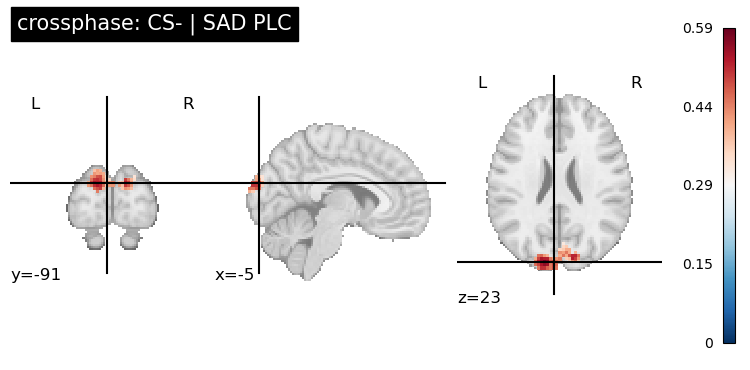

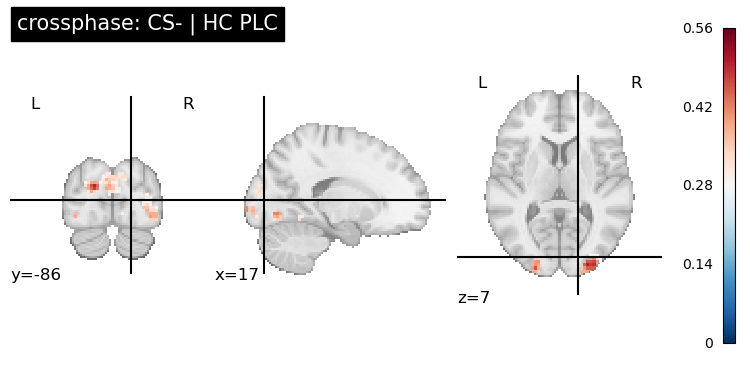

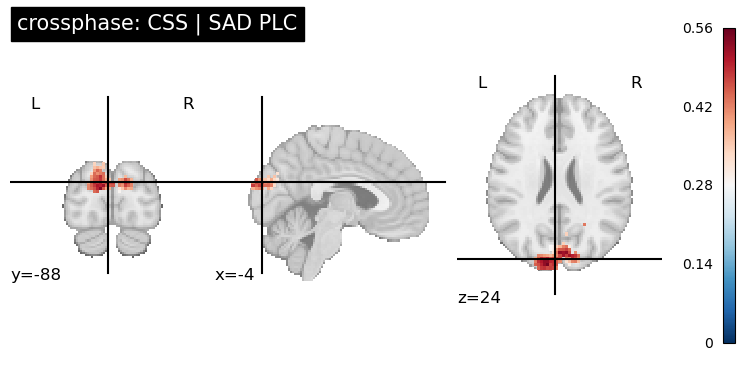

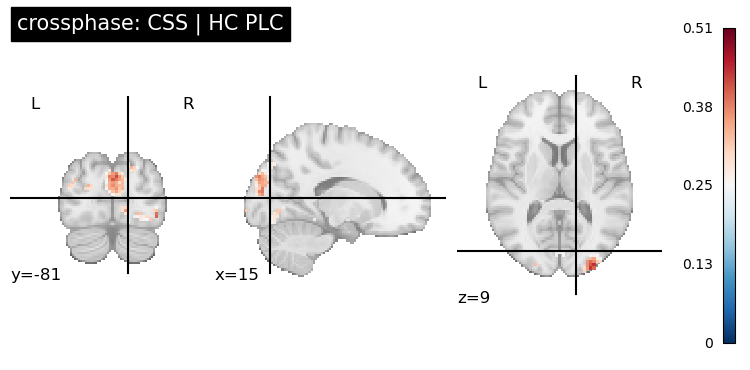

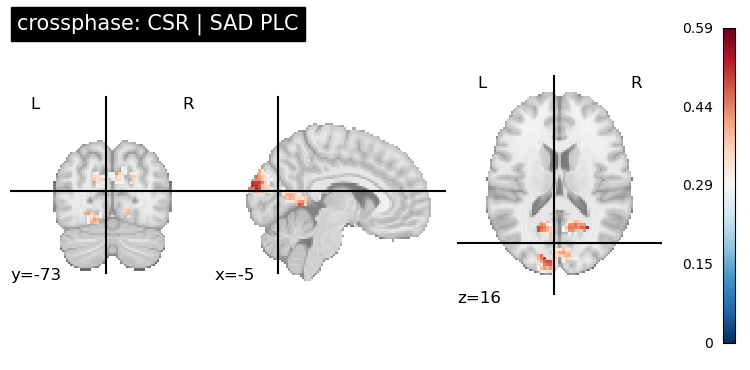

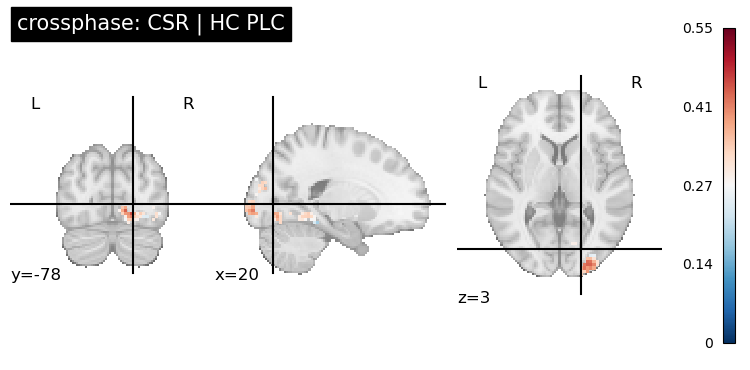

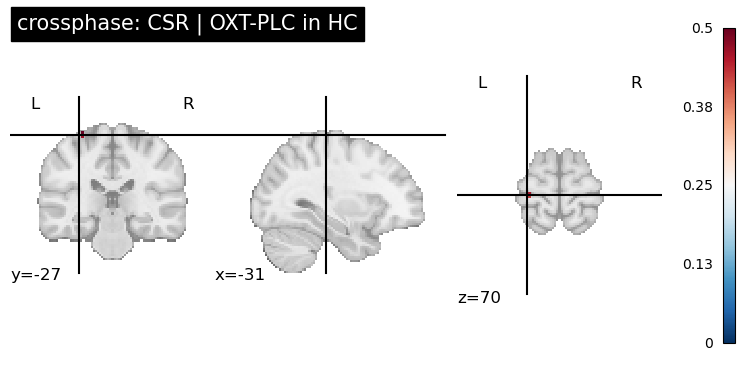

In [8]:
folder = DIRS["crossphase"]
if folder.exists():
    summary_path = folder / "crossphase_summary_contrasts.csv"
    if summary_path.exists():
        print("")
        print("Cross-phase summary contrasts")
        show_csv(summary_path, n=10)

    sig_path = folder / "crossphase_sig_merged.csv"
    if sig_path.exists():
        print("")
        print("Cross-phase significant voxels")
        df = pd.read_csv(sig_path)
        display(df.head(10))
        print(f"Rows: {len(df)}")

    print("")
    print("=== CROSSPHASE ===")
    for cond in CONDS:
        for contrast, label in ORDER:
            base = f"crossphase_{cond}_{contrast}"
            q_path = folder / f"{base}_q.nii.gz"
            if not q_path.exists():
                continue
            effect_path = _effect_path(folder, base)
            if effect_path is None:
                continue
            plot_effect_with_q(effect_path, q_path, title=f"crossphase: {cond} | {label}")

plotting.show()


## EXT / RST: Significant Maps Only


## Dynamic (EXT/RST): Significant Summary + Top Voxels


## Cross-phase: Significant Summary + Top Voxels


## Optional: Only plot significant maps for selected prefixes


In [9]:
# Set to a list of prefixes to limit plots, or leave empty to skip
PREFIXES = []

if PREFIXES:
    for key, folder in DIRS.items():
        if not folder.exists():
            continue
        q_files = [p for p in list_files(folder, '*_q.nii.gz') if any(p.name.startswith(px) for px in PREFIXES)]
        for q_path in q_files:
            base = q_path.name.replace('_q.nii.gz', '')
            effect_path = None
            for suffix in ['_diff.nii.gz', '_mean.nii.gz']:
                candidate = folder / f"{base}{suffix}"
                if candidate.exists():
                    effect_path = candidate
                    break
            if effect_path is None:
                continue
            plot_effect_with_q(effect_path, q_path, title=f"{key}: {base}")

plotting.show()



=== CROSSHALF (H1/H2) ===

--- EXT CROSSHALF ---
Significant voxels (1 voxels): within_CS-_SAD_PLC_H2_q.nii.gz
Significant voxels (3 voxels): mod_CS-_SAD_OXT-PLC_q.nii.gz
Significant voxels (469 voxels): mod_CS-_SAD_OXT-PLC_H1_q.nii.gz
Significant voxels (540 voxels): within_CSS_HC_PLC_H1_q.nii.gz
Significant voxels (11 voxels): mod_CSR_HC_OXT-PLC_q.nii.gz

--- RST CROSSHALF ---
Significant voxels (5 voxels): within_CS-_HC_PLC_H1_q.nii.gz

--- CROSSPHASE CROSSHALF ---
Significant voxels (6 voxels): crossphase_CSR_HC_OXT-PLC_q.nii.gz
Significant voxels (4 voxels): crossphase_CSR_HC_OXT-PLC_H2_q.nii.gz


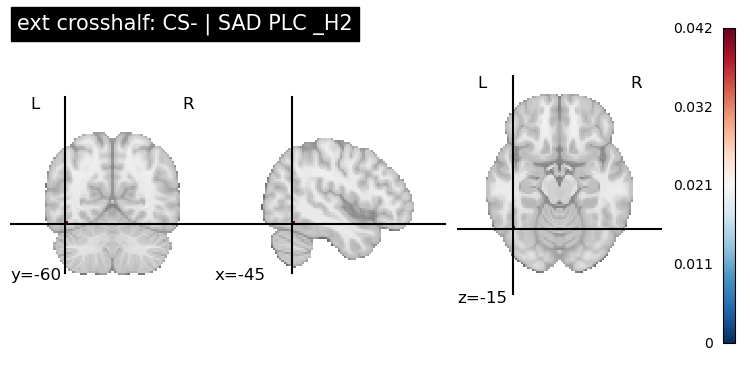

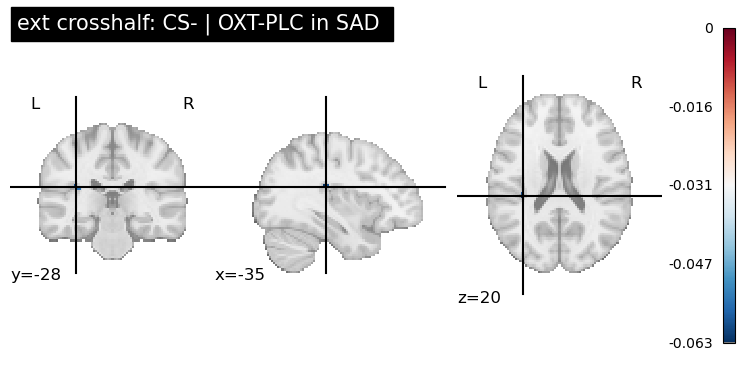

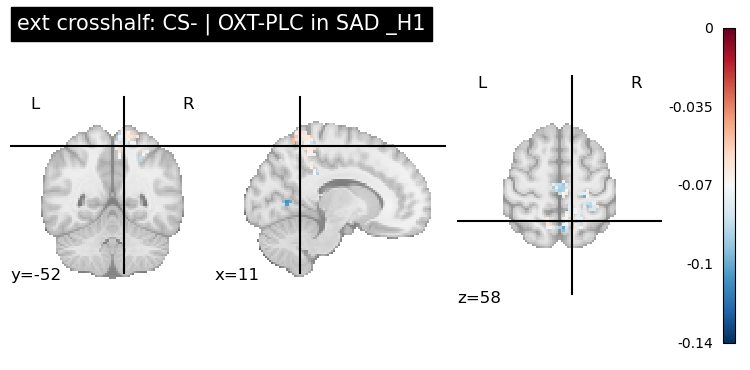

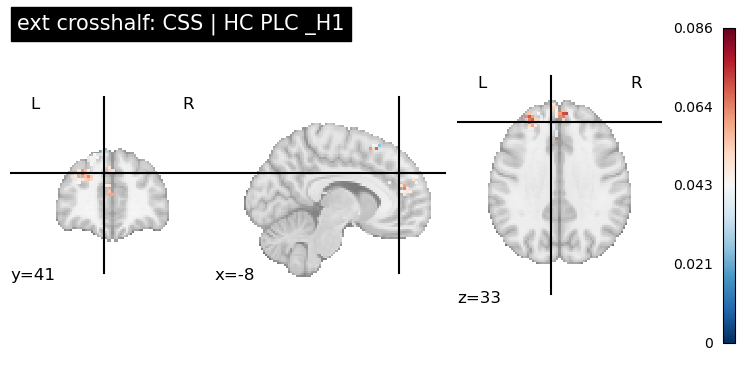

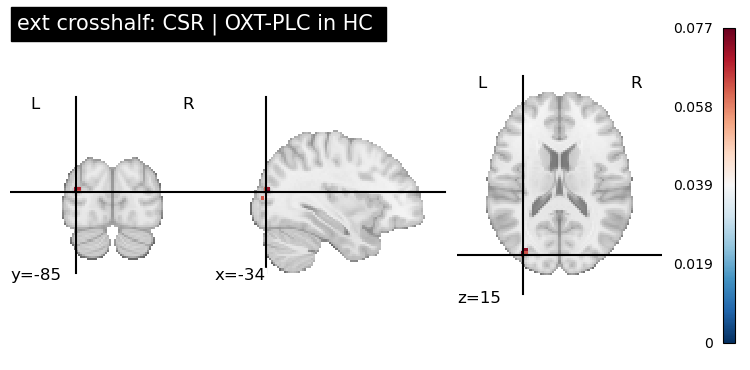

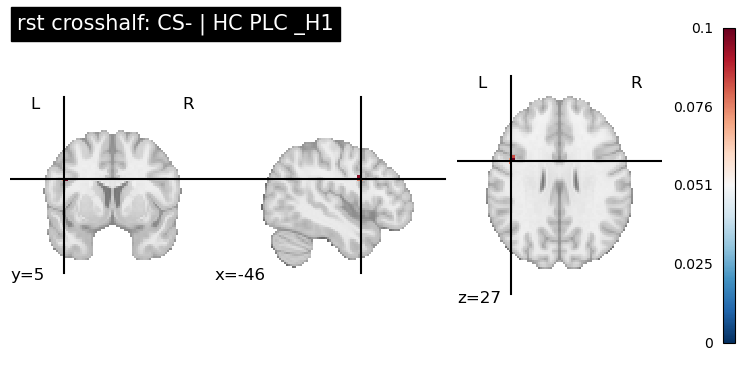

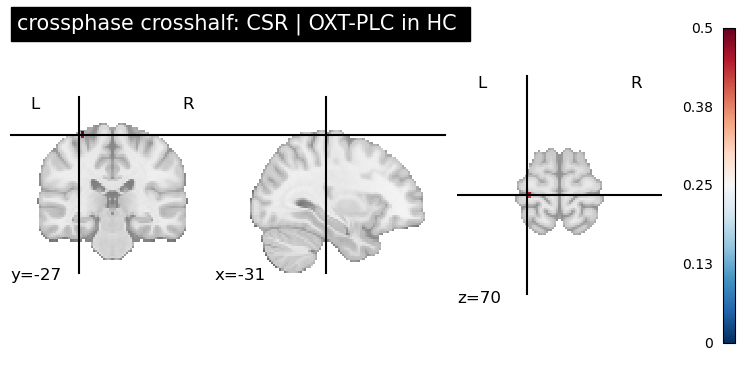

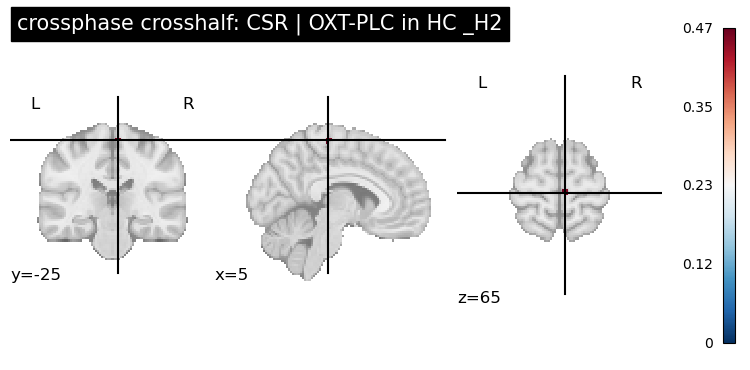

In [10]:
# Cross-half (H1/H2) visualization: sig-only
print("\n=== CROSSHALF (H1/H2) ===")
for key, folder in DIRS_CROSSHALF.items():
    if not folder.exists():
        continue
    print(f"\n--- {key.upper()} CROSSHALF ---")
    if key in ['ext', 'rst']:
        for cond in CONDS:
            for contrast, label in ORDER:
                for suf in HALF_SUFFIXES:
                    if contrast in ["SAD_PLC", "HC_PLC"]:
                        base = f"within_{cond}_{contrast}{suf}"
                    elif contrast == "SAD-HC_PLC":
                        base = f"diff_{cond}_{contrast}{suf}"
                    else:
                        base = f"mod_{cond}_{contrast}{suf}"
                    q_path = folder / f"{base}_q.nii.gz"
                    if not q_path.exists():
                        continue
                    effect_path = _effect_path(folder, base)
                    if effect_path is None:
                        continue
                    plot_effect_with_q(effect_path, q_path, title=f"{key} crosshalf: {cond} | {label} {suf}")

    elif key in ['dyn_ext', 'dyn_rst']:
        for pair in PAIRS:
            for metric in METRICS:
                for contrast, label in ORDER:
                    for suf in HALF_SUFFIXES:
                        base = f"{pair}_{contrast}_{metric}{suf}"
                        q_path = folder / f"{base}_q.nii.gz"
                        if not q_path.exists():
                            continue
                        effect_path = _effect_path(folder, base)
                        if effect_path is None:
                            continue
                        plot_effect_with_q(effect_path, q_path, title=f"{key} crosshalf: {pair} | {metric} | {label} {suf}")

    elif key == 'crossphase':
        for cond in CONDS:
            for contrast, label in ORDER:
                for suf in HALF_SUFFIXES:
                    base = f"crossphase_{cond}_{contrast}{suf}"
                    q_path = folder / f"{base}_q.nii.gz"
                    if not q_path.exists():
                        continue
                    effect_path = _effect_path(folder, base)
                    if effect_path is None:
                        continue
                    plot_effect_with_q(effect_path, q_path, title=f"crossphase crosshalf: {cond} | {label} {suf}")

plotting.show()


In [1]:
import os
from pathlib import Path
import numpy as np
import nibabel as nib

# Define the base path as used in your notebook
BASE = Path('/Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight')

# List of directories to process
DIRS_TO_PROCESS = [
    BASE / 'ext' / 'merged' / 'permutation',
    BASE / 'rst' / 'merged' / 'permutation',
    BASE / 'dyn_ext' / 'merged' / 'permutation',
    BASE / 'dyn_rst' / 'merged' / 'permutation',
    BASE / 'crossphase' / 'merged' / 'permutation',
    BASE / 'ext' / 'crosshalf_permutation',
    BASE / 'rst' / 'crosshalf_permutation',
    BASE / 'dyn_ext' / 'crosshalf_permutation',
    BASE / 'dyn_rst' / 'crosshalf_permutation',
    BASE / 'crossphase' / 'crosshalf_permutation',
]

def load_validmask(q_path: Path) -> np.ndarray | None:
    """Checks for a corresponding validmask file and returns it as a boolean array."""
    base = q_path.name.replace('_q.nii.gz', '')
    vm_path = q_path.parent / f"{base}_validmask.nii.gz"
    if vm_path.exists():
        return nib.load(str(vm_path)).get_fdata() > 0
    return None

def generate_and_save_masks(directories, q_thresh=0.05):
    """Iterates through directories to find q-maps and save significance masks."""
    for folder in directories:
        if not folder.exists():
            print(f"Directory not found: {folder}")
            continue
        
        print(f"Processing: {folder}")
        # Find all q-map files
        q_files = list(folder.glob('*_q.nii.gz'))
        
        for q_path in q_files:
            # Load q-map
            q_img = nib.load(str(q_path))
            q_data = q_img.get_fdata()
            
            # Apply valid mask logic if applicable
            valid = load_validmask(q_path)
            if valid is not None:
                q_data = np.where(valid, q_data, np.nan)
            
            # Create significant mask (1 for sig, 0 otherwise)
            sig_mask_data = ((q_data <= q_thresh) & np.isfinite(q_data)).astype(np.float32)
            
            if np.any(sig_mask_data):
                # Define output path
                mask_name = q_path.name.replace('_q.nii.gz', '_sig_mask.nii.gz')
                mask_path = folder / mask_name
                
                # Save the mask
                mask_img = nib.Nifti1Image(sig_mask_data, q_img.affine, q_img.header)
                nib.save(mask_img, str(mask_path))
                
                n_sig = int(np.sum(sig_mask_data))
                print(f"  [SAVED] {mask_name} ({n_sig} significant voxels)")
            else:
                print(f"  [SKIPPED] {q_path.name} (No significant voxels)")

if __name__ == "__main__":
    generate_and_save_masks(DIRS_TO_PROCESS)

Processing: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/ext/merged/permutation
  [SKIPPED] mod_CSS_HC_OXT-PLC_q.nii.gz (No significant voxels)
  [SKIPPED] mod_CSS_SAD-HC_OXT-PLC_q.nii.gz (No significant voxels)
  [SKIPPED] within_CS-_SAD_PLC_q.nii.gz (No significant voxels)
  [SAVED] mod_CSR_HC_OXT-PLC_sig_mask.nii.gz (11 significant voxels)
  [SKIPPED] diff_CSR_SAD-HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] diff_CSS_SAD-HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] within_CS-_HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] within_CSR_SAD_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] diff_CS-_SAD-HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] within_CSS_HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] mod_CSR_SAD_OXT-PLC_q.nii.gz (No significant voxels)
  [SKIPPED] mod_CS-_HC_OXT-PLC_q.nii.gz (No significant voxels)
  [SAVED] mod_CS-_SAD_OXT-PLC_sig_mask.nii.gz (3 significant voxels)
  [SKIPPED] mod_CSR_SAD-HC_OXT-PLC_q.nii.gz (No significant voxel

In [2]:
import os
from pathlib import Path
import numpy as np
import nibabel as nib

# Define the base path as used in your notebook
BASE = Path('/Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight')

# List of directories to process
DIRS_TO_PROCESS = [
    BASE / 'ext' / 'merged' / 'permutation',
    BASE / 'rst' / 'merged' / 'permutation',
    BASE / 'dyn_ext' / 'merged' / 'permutation',
    BASE / 'dyn_rst' / 'merged' / 'permutation',
    BASE / 'crossphase' / 'merged' / 'permutation',
    BASE / 'ext' / 'crosshalf_permutation',
    BASE / 'rst' / 'crosshalf_permutation',
    BASE / 'dyn_ext' / 'crosshalf_permutation',
    BASE / 'dyn_rst' / 'crosshalf_permutation',
    BASE / 'crossphase' / 'crosshalf_permutation',
]

def load_validmask(q_path: Path) -> np.ndarray | None:
    """Checks for a corresponding validmask file and returns it as a boolean array."""
    base = q_path.name.replace('_q.nii.gz', '')
    vm_path = q_path.parent / f"{base}_validmask.nii.gz"
    if vm_path.exists():
        return nib.load(str(vm_path)).get_fdata() > 0
    return None

def generate_and_save_masks(directories, q_thresh=0.05):
    """Iterates through directories to find q-maps and save significance masks."""
    for folder in directories:
        if not folder.exists():
            print(f"Directory not found: {folder}")
            continue
        
        print(f"Processing: {folder}")
        # Find all q-map files
        q_files = list(folder.glob('*_q.nii.gz'))
        
        for q_path in q_files:
            # Load q-map
            q_img = nib.load(str(q_path))
            q_data = q_img.get_fdata()
            
            # Apply valid mask logic if applicable
            valid = load_validmask(q_path)
            if valid is not None:
                q_data = np.where(valid, q_data, np.nan)
            
            # Create significant mask (1 for sig, 0 otherwise)
            sig_mask_data = ((q_data <= 0.1) & np.isfinite(q_data)).astype(np.float32)
            
            if np.any(sig_mask_data):
                # Define output path
                mask_name = q_path.name.replace('_q.nii.gz', '_q0.9_mask.nii.gz')
                mask_path = folder / mask_name
                
                # Save the mask
                mask_img = nib.Nifti1Image(sig_mask_data, q_img.affine, q_img.header)
                nib.save(mask_img, str(mask_path))
                
                n_sig = int(np.sum(sig_mask_data))
                print(f"  [SAVED] {mask_name} ({n_sig} significant voxels)")
            else:
                print(f"  [SKIPPED] {q_path.name} (No significant voxels)")

if __name__ == "__main__":
    generate_and_save_masks(DIRS_TO_PROCESS)

Processing: /Users/xiaoqianxiao/projects/NARSAD/LSS/searchlight/ext/merged/permutation
  [SKIPPED] mod_CSS_HC_OXT-PLC_q.nii.gz (No significant voxels)
  [SKIPPED] mod_CSS_SAD-HC_OXT-PLC_q.nii.gz (No significant voxels)
  [SKIPPED] within_CS-_SAD_PLC_q.nii.gz (No significant voxels)
  [SAVED] mod_CSR_HC_OXT-PLC_q0.9_mask.nii.gz (222 significant voxels)
  [SKIPPED] diff_CSR_SAD-HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] diff_CSS_SAD-HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] within_CS-_HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] within_CSR_SAD_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] diff_CS-_SAD-HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] within_CSS_HC_PLC_q.nii.gz (No significant voxels)
  [SKIPPED] mod_CSR_SAD_OXT-PLC_q.nii.gz (No significant voxels)
  [SAVED] mod_CS-_HC_OXT-PLC_q0.9_mask.nii.gz (13 significant voxels)
  [SAVED] mod_CS-_SAD_OXT-PLC_q0.9_mask.nii.gz (71 significant voxels)
  [SKIPPED] mod_CSR_SAD-HC_OXT-PLC_q.nii.gz (No signifi

In [17]:
import os
from pathlib import Path
import numpy as np
import nibabel as nib
from nilearn import datasets, image

# --- Configuration Variables ---
# Target functional file for dimensions/affine (3.0mm, 53x65x56)
TARGET_FUNC = Path("/Users/xiaoqianxiao/Downloads/func/sub-N109_ses-01_task-phase2_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz")
OUTPUT_DIR = Path("/Users/xiaoqianxiao/tool/parcellation/ROIs/NARSAD_multi_lateral_3mm")

PROB_THRESHOLD = 0.25  # 25% probability threshold
ATLAS_NAME = 'cort-prob-2mm'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_lateral_ho_masks():
    # 1. Fetch the HO atlas
    atlas = datasets.fetch_atlas_harvard_oxford(ATLAS_NAME)
    maps = atlas.maps 
    labels = atlas.labels[1:]  # Skip 'Background'
    
    if isinstance(maps, str):
        prob_img = nib.load(maps)
    else:
        prob_img = maps
        
    prob_data = prob_img.get_fdata()
    affine = prob_img.affine
    header = prob_img.header

    # Create an X-coordinate map to distinguish hemispheres
    # In MNI space, X < 0 is Left, X > 0 is Right
    coords = np.zeros(prob_data.shape[:3])
    for x in range(prob_data.shape[0]):
        # Convert voxel index to MNI x-coordinate using the affine
        mni_x = affine[0, 0] * x + affine[0, 3]
        coords[x, :, :] = mni_x

    left_hemi_mask = coords < 0
    right_hemi_mask = coords > 0

    # 2. Define the Region Groupings
    # --- Updated Region Groupings ---
    region_definitions = {
        "VVC": [
            "Lateral Occipital Cortex, inferior division",
            "Occipital Fusiform Gyrus",
            "Temporal Fusiform Gyrus, anterior division",
            "Temporal Fusiform Gyrus, posterior division",
            "Parahippocampal Gyrus, anterior division",
            "Parahippocampal Gyrus, posterior division"
        ],
        "AG": ["Angular Gyrus"],
        "SMG": [
            "Supramarginal Gyrus, anterior division", 
            "Supramarginal Gyrus, posterior division"
        ],
        "IFG": [
            "Inferior Frontal Gyrus, pars triangularis", 
            "Inferior Frontal Gyrus, pars opercularis"
        ],
        "MFG": ["Middle Frontal Gyrus"],
        "SFG": ["Superior Frontal Gyrus"],
        "Precuneus": ["Precuneous Cortex"]  # Added Precuneus
    }

    print(f"Targeting Dimensions: {nib.load(str(TARGET_FUNC)).shape[:3]}")

    for roi_name, constituent_labels in region_definitions.items():
        combined_prob_map = np.zeros(prob_data.shape[:3])

        for label in constituent_labels:
            if label in labels:
                idx = labels.index(label)
                combined_prob_map += prob_data[..., idx]
        
        # Binarize based on threshold
        full_binary_mask = (combined_prob_map > (PROB_THRESHOLD * 100))

        # 3. Split into Left and Right
        hemispheres = {
            "left": full_binary_mask & left_hemi_mask,
            "right": full_binary_mask & right_hemi_mask
        }

        for hemi, mask_data in hemispheres.items():
            # Create temporary Nifti at 2mm
            temp_img = nib.Nifti1Image(mask_data.astype(np.float32), affine, header)
            
            # 4. Resample to 3mm Functional Dimension (53, 65, 56)
            # Use 'nearest' interpolation to preserve binary 0/1 values
            resampled_roi = image.resample_to_img(
                source_img=temp_img,
                target_img=str(TARGET_FUNC),
                interpolation='nearest',
                copy_header=True,
                force_resample=True
            )
            
            output_filename = OUTPUT_DIR / f"{hemi}_{roi_name}.nii.gz"
            nib.save(resampled_roi, str(output_filename))
            
            v_count = int(np.sum(resampled_roi.get_fdata() > 0))
            print(f"  [SAVED] {hemi}_{roi_name} -> {v_count} voxels")

if __name__ == "__main__":
    generate_lateral_ho_masks()

[fetch_atlas_harvard_oxford] Dataset found in /Users/xiaoqianxiao/nilearn_data/fsl

Targeting Dimensions: (53, 65, 56)
  [SAVED] left_VVC -> 1336 voxels
  [SAVED] right_VVC -> 1324 voxels
  [SAVED] left_AG -> 347 voxels
  [SAVED] right_AG -> 479 voxels
  [SAVED] left_SMG -> 699 voxels
  [SAVED] right_SMG -> 690 voxels
  [SAVED] left_IFG -> 466 voxels
  [SAVED] right_IFG -> 430 voxels
  [SAVED] left_MFG -> 852 voxels
  [SAVED] right_MFG -> 791 voxels
  [SAVED] left_SFG -> 785 voxels
  [SAVED] right_SFG -> 708 voxels
  [SAVED] left_Precuneus -> 777 voxels
  [SAVED] right_Precuneus -> 852 voxels
